<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hiranawaz2415","key":"7ade3180923fb5ac9db4b376a34cc842"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d iabhishekofficial/mobile-price-classification

Dataset URL: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification
License(s): unknown
100% 70.6k/70.6k [00:00<00:00, 499kB/s]



In [5]:
!unzip mobile-price-classification.zip

Archive:  mobile-price-classification.zip
  inflating: test.csv                
  inflating: train.csv               


In [9]:
# ================================
#  1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# ================================
#  2. LOAD DATASET
# ================================
data = pd.read_csv("train.csv")
# Separate features and target
X = data.drop("price_range", axis=1).values   # shape (2000, 20)
y = data["price_range"].values

In [11]:
print(data.shape)
print(data.columns)

(2000, 21)
Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [12]:
# ================================
#  3. NORMALIZE FEATURES
# ================================
# Important for neural networks
X = (X - X.mean(axis=0)) / X.std(axis=0)


In [13]:
# ================================
#  4. ONE-HOT ENCODING (4 classes)
# ================================
def one_hot(y, num_classes=4):
    out = np.zeros((y.size, num_classes))
    out[np.arange(y.size), y] = 1
    return out


In [14]:
y = one_hot(y)

In [15]:
y

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [16]:
# ================================
#  5. FORCE OVERFITTING
# ================================
# Use very small training data
X_train = X[:100]
y_train = y[:100]
# Remaining for testing
X_test = X[100:]
y_test = y[100:]

In [17]:
# ================================
# 6. INITIALIZE PARAMETERS
# ================================
np.random.seed(42)
# Input = 20 features
# Hidden layers = 128 neurons
# Output = 4 classes
W1 = np.random.randn(20, 128) * 0.01
b1 = np.zeros((1, 128))
W2 = np.random.randn(128, 128) * 0.01
b2 = np.zeros((1, 128))
W3 = np.random.randn(128, 4) * 0.01
b3 = np.zeros((1, 4))


In [18]:
# ================================
#  7. ACTIVATION FUNCTIONS
# ================================
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)


### Model Architecture
Feedforward Neural Network (Multilayer Perceptron - MLP)
 - Input Layer:     
 - 20 neurons  (features)
 - Hidden Layer 1:  128 neurons (ReLU)
 - Hidden Layer 2:  128 neurons (ReLU)
 - Output Layer:     4 neurons  (Softmax)

##### Output Layer
- 4 neurons → represent classes:
- 0 → Low price
- 1 → Medium
- 2 → High
- 3 → Very high


Softmax use to Converts output into probabilities

In [19]:
# ================================
#  8. FORWARD PROPAGATION
# ================================
def forward(X):
    Z1 = X.dot(W1) + b1
    A1 = relu(Z1)

    Z2 = A1.dot(W2) + b2
    A2 = relu(Z2)

    Z3 = A2.dot(W3) + b3
    A3 = softmax(Z3)

    cache = (Z1, A1, Z2, A2, Z3, A3)
    return A3, cache

In [20]:
# ================================
#  9. LOSS FUNCTION
# ================================
def loss(Y, A):
    return -np.mean(np.sum(Y * np.log(A + 1e-8), axis=1))

In [21]:
# ================================
#  10. BACKPROPAGATION
# ================================
def backward(X, Y, cache):
    global W1, W2, W3

    Z1, A1, Z2, A2, Z3, A3 = cache
    m = X.shape[0]

    # Output layer
    dZ3 = A3 - Y
    dW3 = A2.T.dot(dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Hidden layer 2
    dA2 = dZ3.dot(W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T.dot(dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer 1
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T.dot(dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [22]:
# ================================
# 11. TRAINING LOOP
# ================================
lr = 0.01
epochs = 300

train_losses = []
test_losses = []

for i in range(epochs):

    # Forward pass (training)
    A_train, cache = forward(X_train)
    train_loss = loss(y_train, A_train)

    # Forward pass (testing)
    A_test, _ = forward(X_test)
    test_loss = loss(y_test, A_test)

    # Store losses
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Backpropagation
    grads = backward(X_train, y_train, cache)
    dW1, db1, dW2, db2, dW3, db3 = grads

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3

    if i % 20 == 0:
        print(f"Epoch {i}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")


Epoch 0, Train Loss: 1.3863, Test Loss: 1.3863
Epoch 20, Train Loss: 1.3858, Test Loss: 1.3863
Epoch 40, Train Loss: 1.3853, Test Loss: 1.3864
Epoch 60, Train Loss: 1.3849, Test Loss: 1.3865
Epoch 80, Train Loss: 1.3845, Test Loss: 1.3865
Epoch 100, Train Loss: 1.3842, Test Loss: 1.3866
Epoch 120, Train Loss: 1.3839, Test Loss: 1.3868
Epoch 140, Train Loss: 1.3836, Test Loss: 1.3869
Epoch 160, Train Loss: 1.3834, Test Loss: 1.3870
Epoch 180, Train Loss: 1.3831, Test Loss: 1.3871
Epoch 200, Train Loss: 1.3829, Test Loss: 1.3873
Epoch 220, Train Loss: 1.3827, Test Loss: 1.3874
Epoch 240, Train Loss: 1.3826, Test Loss: 1.3876
Epoch 260, Train Loss: 1.3824, Test Loss: 1.3877
Epoch 280, Train Loss: 1.3823, Test Loss: 1.3878


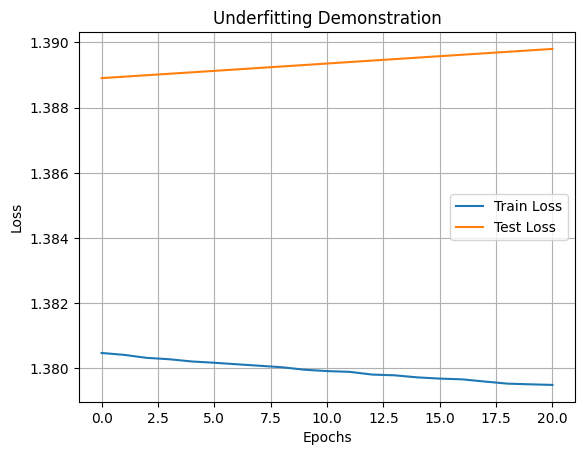

In [73]:
# ================================
#  12. PLOT LOSS CURVE
# ================================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Underfitting Demonstration")

plt.legend()
plt.grid(True)
plt.show()


In [24]:
# ================================
#  13. ACCURACY FUNCTION
# ================================
def accuracy(X, Y):
    A, _ = forward(X)
    pred = np.argmax(A, axis=1)
    true = np.argmax(Y, axis=1)
    return np.mean(pred == true)



In [25]:
print("Train Accuracy:", accuracy(X_train, y_train))
print("Test Accuracy:", accuracy(X_test, y_test))

Train Accuracy: 0.29
Test Accuracy: 0.24789473684210525
